In [51]:
#Importación de librerías
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans


In [2]:
#Carga del dataset como df_total
df_total = pd.read_csv('C:/Users/corre/Documents/_UNIR/3er semestre/Seminario de Innovacion en Analisis y Visualizacion de Datos Masivos/Entrega 02/D3_sales20250401-20250630.csv',encoding='ISO-8859-1')

In [3]:
#Tomar los primeros 1000 registros
df=df_total.head(1000)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1000 non-null   object 
 1   time         1000 non-null   object 
 2   store        1000 non-null   int64  
 3   ticket       1000 non-null   int64  
 4   product      1000 non-null   int64  
 5   description  1000 non-null   object 
 6   quantity     1000 non-null   float64
 7   price        1000 non-null   float64
 8   total        1000 non-null   float64
 9   employee     1000 non-null   object 
 10  physician    1000 non-null   object 
 11  customer     1000 non-null   object 
 12  brand        1000 non-null   object 
 13  laboratory   1000 non-null   object 
 14  type         1000 non-null   object 
 15  category     1000 non-null   object 
dtypes: float64(3), int64(3), object(10)
memory usage: 125.1+ KB


In [7]:
df.head()

,date,time,store,ticket,product,description,quantity,price,total,employee,physician,customer,brand,laboratory,type,category
0,2025-04-01,08:31:33,1,163366,656599040110,ATENOLOL 100MG TAB 28,1.0,77.00,77.00,CYNTHIA JANETH ALVAREZ AGUILER,SIN CEDULA,XAXX010101000,INTERNOL,VICTORY,SIMILARES,MEDICAMENTO
1,2025-04-01,08:37:42,1,163367,7506442700889,QUETIAPINA FUMARATO 25MG TAB 30,1.0,282.00,282.00,JAQUELINE OLVERA BURGOS,SIN CEDULA,XAXX010101000,QUETIAPINA,CAMBER,SIMILARES,MEDICAMENTO
2,2025-04-01,08:53:25,1,163368,8901120011735,ATOMOXETINA 25MG CAP 14,1.0,372.00,372.00,CYNTHIA JANETH ALVAREZ AGUILER,3413491,XAXX010101000,MOXAZYD,ZYDUS,PATENTE,MEDICAMENTO
3,2025-04-01,08:53:25,1,163368,650240012525,PRESERVATIVO 100% BLISTER 3 PIEZAS,1.0,58.15,58.15,CYNTHIA JANETH ALVAREZ AGUILER,3413491,XAXX010101000,M ULTRA SENSIBLES,GENOMA LAB,PATENTE,OTC
4,2025-04-01,08:53:25,1,163368,7501086801046,AGUA PURIFICADA 100% BOTELLA 1 LT,1.0,11.00,11.00,CYNTHIA JANETH ALVAREZ AGUILER,3413491,XAXX010101000,E-PURA,PEPSI,PATENTE,ABARROTES


In [8]:
df.isnull().sum()

date           0
time           0
store          0
ticket         0
product        0
description    0
quantity       0
price          0
total          0
employee       0
physician      0
customer       0
brand          0
laboratory     0
type           0
category       0
dtype: int64

In [9]:
# Convertir columna 'date' a datetime

#df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], dayfirst=True)
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='mixed', dayfirst=True)
df['month'] = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.day_name()

# Verificar valores nulos
print(df.isnull().sum())

date           0
time           0
store          0
ticket         0
product        0
description    0
quantity       0
price          0
total          0
employee       0
physician      0
customer       0
brand          0
laboratory     0
type           0
category       0
datetime       0
month          0
day_of_week    0
dtype: int64


C:\Users\corre\AppData\Local\Temp\ipykernel_37464\889842833.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='mixed', dayfirst=True)
C:\Users\corre\AppData\Local\Temp\ipykernel_37464\889842833.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['datetime'].dt.month
C:\Users\corre\AppData\Local\Temp\ipykernel_37464\889842833.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

In [10]:
#Eliminar valores nulos 
df = df.dropna()

In [11]:
# Crear dataset para modelado
df_model = df[['quantity', 'price', 'month', 'day_of_week', 'store', 'type', 'category', 'laboratory']]

# Convertir variables categóricas
df_model = pd.get_dummies(df_model, columns=['day_of_week', 'type', 'category', 'laboratory'], drop_first=True)

# Eliminar NaN por si acaso
df_model = df_model.dropna()

# Separar 'X' y 'y'
#Definicion de las variables Explicativas (X) y variable objetivo (y)
X = df_model.drop('quantity', axis=1)
y = df_model['quantity']


In [12]:
# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
#Modelo 1: Random Forest 
#Entrenar modelo predictivo
model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)

RandomForestRegressor()

In [14]:
#Modelo 2: GBR, Gradient Boosting Regressor
model_gbr = GradientBoostingRegressor(random_state=42)
model_gbr.fit(X_train, y_train)
y_pred_gbr = model_gbr.predict(X_test)

In [15]:
# Predicción y evaluación
y_pred_rf = model_rf.predict(X_test)

#Mean Square error
MSE_rf = mean_squared_error(y_test, y_pred_rf)
print("MSE: ", MSE_rf)

#Root mean square error
RMSE_rf = np.sqrt(MSE_rf)
print("RMSE: ", RMSE_rf)

#Mean absolute error
MAE_rf = mean_absolute_error(y_test, y_pred_rf)
print("MAE: ", MAE_rf)

#R-cuadrada (Coeficiente de determinacion)
r2_rf = r2_score(y_test, y_pred_rf)
print("R²: ", r2_rf)

MSE:  0.5263524961305491
RMSE:  0.7255015479863217
MAE:  0.2944218464868465
R²:  -0.6742822938546291


In [16]:
# Predicción y evaluación
y_pred2 = model_gbr.predict(X_test)

#Mean Square error
MSE_gbr = mean_squared_error(y_test, y_pred_gbr)
print("MSE: ", MSE_gbr)

#Root mean square error
RMSE_gbr = np.sqrt(MSE_gbr)
print("RMSE: ", RMSE_gbr)

#Mean absolute error
MAE_gbr = mean_absolute_error(y_test, y_pred_gbr)
print("MAE: ", MAE_gbr)

#R-cuadrada (Coeficiente de determinacion)
r2_gbr = r2_score(y_test, y_pred_gbr)
print("R²: ", r2_gbr)

MSE:  0.8695564307265857
RMSE:  0.9325000969043304
MAE:  0.3583989382707023
R²:  -1.7659846703032547


In [17]:
#Matriz para visualizar resultados de ambos modelos

#Separacion de modelos
rf = [MSE_rf, RMSE_rf, MAE_rf, r2_rf]  
gbr = [MSE_gbr, RMSE_gbr, MAE_gbr, r2_gbr] 

#Creacion del dataframe
matriz = pd.DataFrame({
    "MSE": [rf[0], gbr[0]],
    "RMSE": [rf[1], gbr[1]],
    "MAE": [rf[2], gbr[2]],
    "R2": [rf[3], gbr[3]],
}, index=["Random Forest", "Gradient Boosting"])

#Visualizacion en forma de matriz entre ambos modelos para mejor comparacion 
print(matriz)

                        MSE      RMSE       MAE        R2
Random Forest      0.526352  0.725502  0.294422 -0.674282
Gradient Boosting  0.869556  0.932500  0.358399 -1.765985


In [18]:
#Modelo prescriptivo (Recomendación de usuario)
avg_demand = df.groupby(['store', 'description'])['quantity'].mean().reset_index()
avg_demand['recomendacion'] = avg_demand['quantity'].apply(
    lambda x: 'ALTO' if x >= 5 else 'MEDIO' if x >= 2 else 'BAJO'
)

C:\Users\corre\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


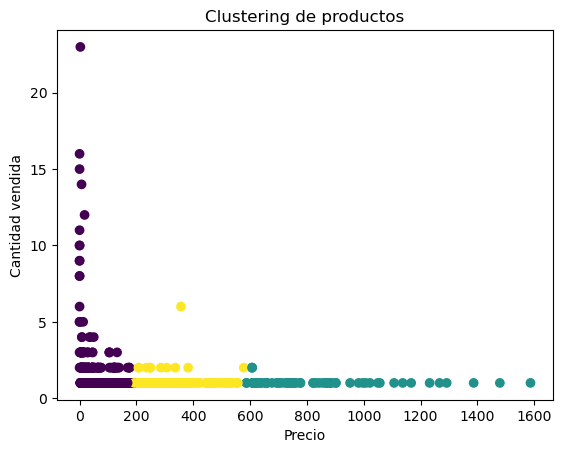

In [19]:
#Clustering 
X2 = df[['price', 'quantity']]
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['cluster'] = kmeans.fit_predict(X2)

plt.scatter(df['price'], df['quantity'], c=df['cluster'], cmap='viridis')
plt.xlabel('Precio')
plt.ylabel('Cantidad vendida')
plt.title('Clustering de productos')
plt.show()

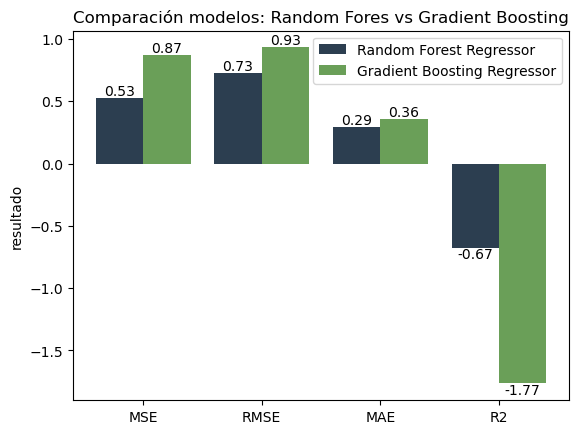

In [50]:
#Definicion de la variable con los nombres de las tecnicas de evaluacion
columnas = ["MSE", "RMSE", "MAE", "R2"]

#crear array con los nombres de las columnas
x = np.arange(len(columnas))
#ancho de cada barra
width = 0.4

#deficion del grafico
fig, ax = plt.subplots()
#barras del random fores
barras_rf = ax.bar(x - width/2, rf, width, color = "#2C3E50", label = "Random Forest Regressor")
#Barras del GBR
barras_gbr = ax.bar(x + width/2, gbr, width, color = "#6A9F58", label = "Gradient Boosting Regressor")
ax.legend()     #Mostrar legenda y sus colores
ax.set_title("Comparación modelos: Random Fores vs Gradient Boosting")    #Titulo
ax.set_xticks(x)    #etiquetas en el eje x
ax.set_xticklabels(columnas)    #Clumnas como etiquetas
ax.set_ylabel("resultado")       #Etiqueta en el eje y

#etiquetas con los valores de cada modelo y evaluacion
ax.bar_label(barras_rf, fmt = "%.2f")    #Limitar a dos decimales
ax.bar_label(barras_gbr, fmt = "%.2f")

#Mostrar grafico
plt.show()